# Predictive maintenance of NASA Turbofan Jet Engines

This notebook atempts to predict remaining useful life (RUL) of a NASA Turbofan Jet Engine.

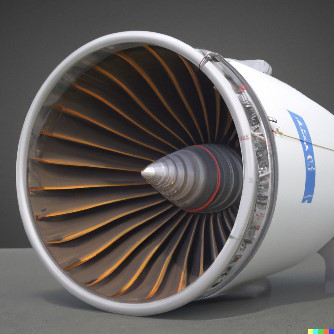

### Table of Content
* [Globals and Classes](#Globals-and-Classes)
* [Visualization and selection](#Visualization-and-selection)
* [Data preparation](#Data-preparation)
* [Building the model structures](#Building-the-model-structures)
* [Training](#Training)
* [Evaluation of training results](#Evaluation-of-training-results)
* [Prediction](#Prediction)
* [Evaluation of predictions](#Evaluation-of-predictions)


### Globals and Classes

In [1]:
import pandas as pd
import numpy as np

In [2]:
class Data:
    from sklearn.preprocessing import MinMaxScaler
    def __init__(self):
        self.train = pd.read_csv('lib/train_FD001.csv')
        self.test = pd.read_csv('lib/train_FD001.csv')
        self.features = None
        self.target_linear = None
        self.target_binary = None
    
    def generate_label_df(self, dataframe, target, sequence):
        # Return a "label" dataframe with length = sequence 
        label = dataframe[target].loc[:sequence.shape[0] - 1]
        return label

    def generate_sequence(self, dataframe, sequence_length):
        # Set dimentions
        width = sequence_length
        height = dataframe.shape[0] - width
        depth = len(self.features)
        # Generate empty array of desired dimentions
        sequence = np.zeros((height, width, depth))
        # Populate array
        for i in range(depth):
            for j in range(height):
                for k in range(width):
                    sequence[j, k, i] = dataframe[self.features[i]].loc[k + j]
        return sequence
    
    def add_failsoon_column(self, dataframe, foresight):
        failsoon_column = np.where(dataframe[self.target_linear] <= foresight, 1, 0)
        return failsoon_column
    
    def scale_features(self, dataframe):
        scale = self.MinMaxScaler()
        dataframe[self.features] = scale.fit_transform(dataframe[self.features])

data = Data()

In [3]:
class Prepared:
    def __init__(self, train, test):
        self.train = train
        self.test = test
        self.train_sequence = None
        self.test_sequence = None
        self.train_label = None
        self.test_label = None

In [ ]:
class Plot:
    import matplotlib.pyplot as plt
    import seaborn as sns
    import warnings
    plt.style.use('bmh')
    
    def __init__(self):
        self.cycles = data.train["cycle"]
        self.sensors = self.create_sensor_list()

    def create_sensor_list(self):
        sensors = []
        for i in range(1,22):
            sensors += ["sensor" + " " + str(i)]
        return sensors

    def timeseries_single_engine(self, engine):
        single_engine_data = data.train[data.train["engine"] == engine]
        colors = iter(self.plt.cm.plasma(np.linspace(0, 1, 21)))
        for i in range(0,21):
            c = next(colors)
            self.plt.figure(1, figsize=(12, 18))
            self.plt.subplot(22//2, 2, i+1)
            self.plt.plot(single_engine_data[self.sensors[i]], c=c, label=self.sensors[i])
            self.plt.legend(), self.plt.tight_layout(), self.plt.grid(True)

    def corr_scatter(self):
        with self.warnings.catch_warnings(record=True):
            for i in range(0,21):
                self.plt.figure(1, figsize=(12, 20))
                self.plt.subplot(22//3, 3, i+1)
                self.plt.scatter(
                x=data.train[self.sensors[i]], y=data.train["RUL"], s=2,
                alpha=0.3, c=self.cycles, cmap=self.plt.get_cmap("plasma"))
                self.plt.colorbar(label = "cycles"), self.plt.tight_layout()
                self.plt.xlabel(self.sensors[i]), self.plt.ylabel("RUL")
                self.plt.grid(True)
    
    def corr_heatmap(self, dataframe, plot_title, corr_method):
        dataframe = dataframe.corr(method=corr_method)
        self.plt.figure(1, figsize=(16, 12))
        self.sns.heatmap(dataframe.round(3), 
            xticklabels=True, yticklabels=True, 
            cmap="plasma", annot=True)
        self.plt.gcf()
        self.plt.title(plot_title)
        self.plt.show()

    def fit_evaluation(self, fit_result, metric, plot_title):
        valid = {'mae', 'loss'}
        if metric not in valid:
            raise ValueError("fit_evaluation: metric must be one of %r." % valid)
        self.plt.figure(1, figsize=(10, 8))
        self.plt.plot(fit_result.history[metric], c='magenta')
        self.plt.plot(fit_result.history['val_' + metric], c='darkturquoise')
        self.plt.title(plot_title)
        self.plt.ylabel(metric)
        self.plt.xlabel('epoch')
        self.plt.legend(['Train', 'Validation'])
        self.plt.show()
    
    def pred_evaluation(self, y_label, y_pred, cycle_start, cycle_stop):
        _y_label = y_label.to_numpy()
        self.plt.figure(1, figsize=(18, 5))
        self.plt.plot(_y_label[cycle_start : cycle_stop], c='darkturquoise')
        self.plt.plot(y_pred[cycle_start : cycle_stop], c='magenta', linestyle='dashed', alpha=0.8)
        self.plt.title('Model prediction')
        self.plt.ylabel('Failsoon')
        self.plt.xlabel('cycles')
        self.plt.legend(['y_label', 'y_pred'])
        self.plt.show()

plot = Plot()

### Visualization and selection

To visualize the data, we can plot timeseries from one of the engines.

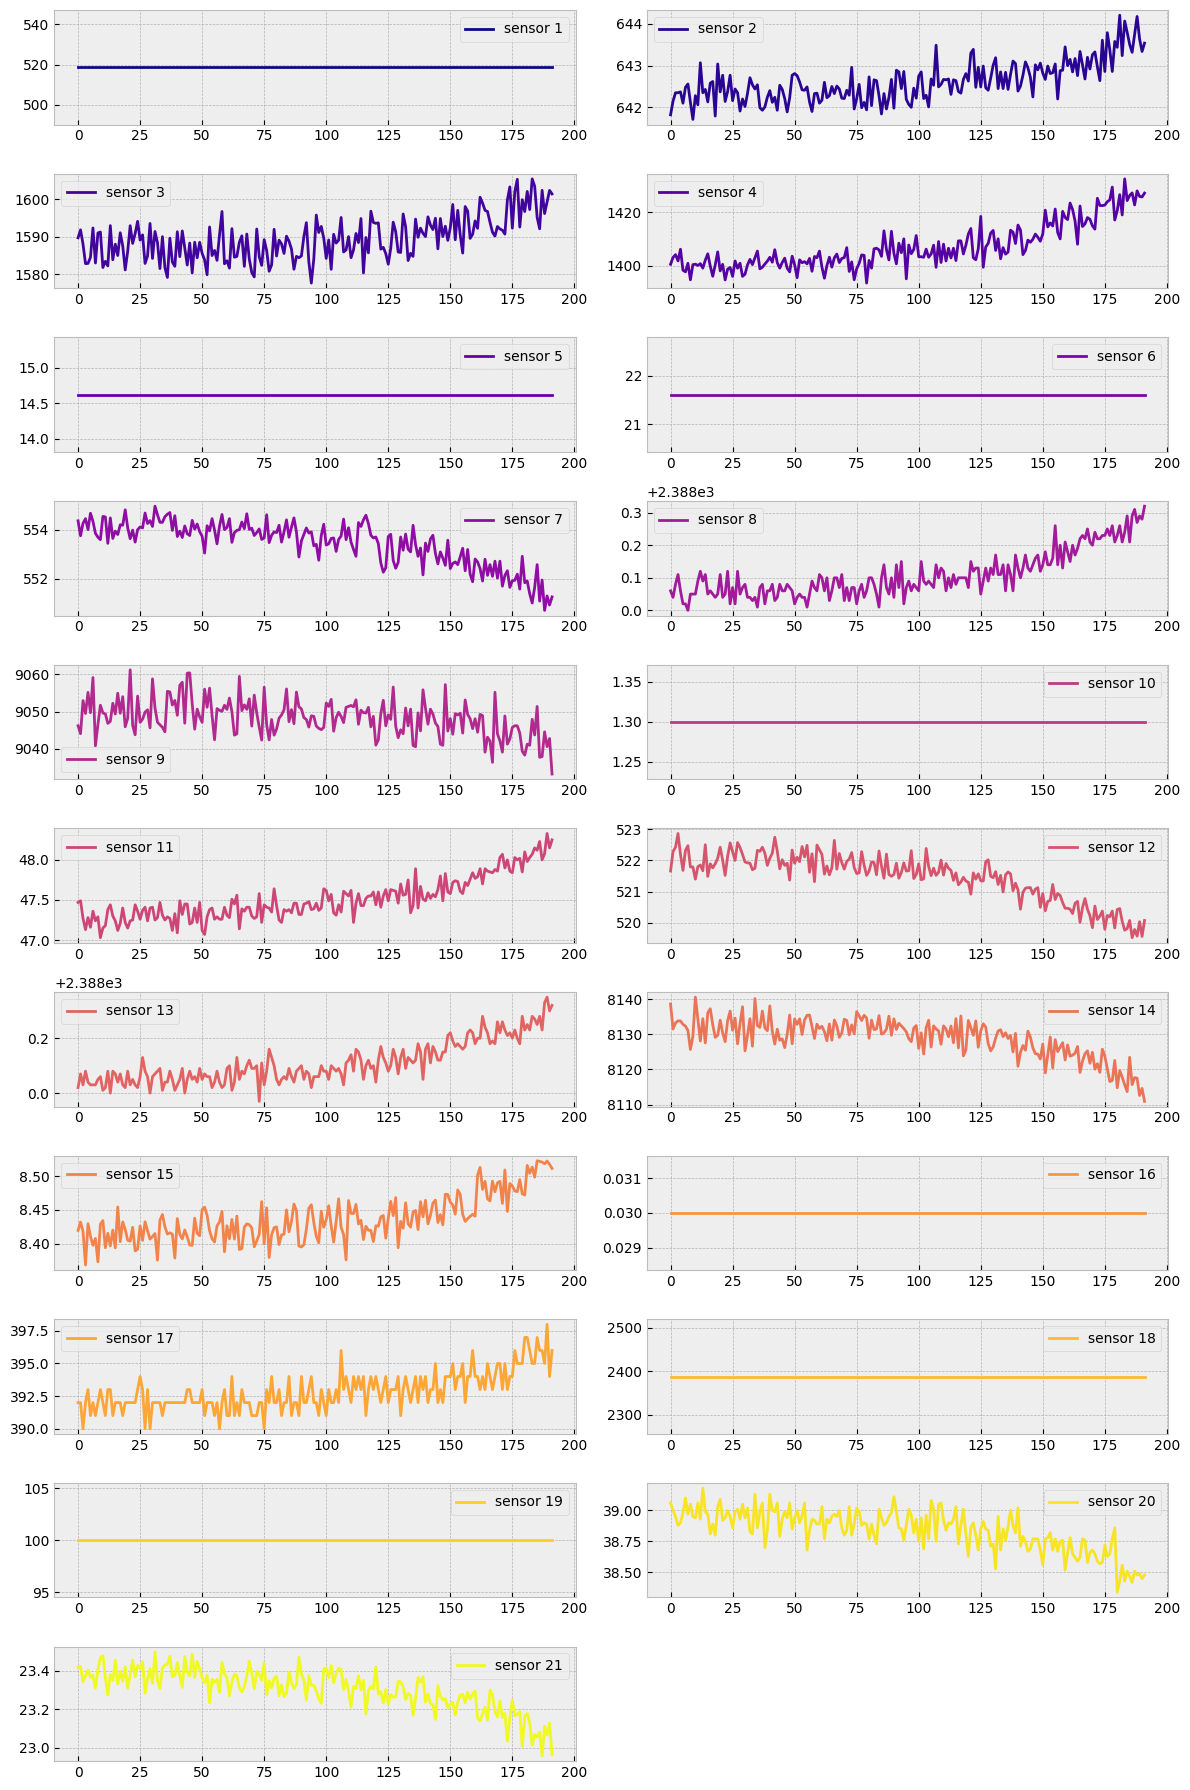

In [5]:
plot.timeseries_single_engine(1)

#### Correlation scatterplots

A way to visualize the data and simultaneously consider correlation is by using scatterplots of feature vs target. In our case, the target is remaining useful life (RUL) and features is the sensors provided. Since there are many engines, the data from the features will be layered on top of each other with no apparent visualization of the cycle number from each of the engines. To aid in this, a color map of the cycles is added to see where in the cycle range each datapoint resides.

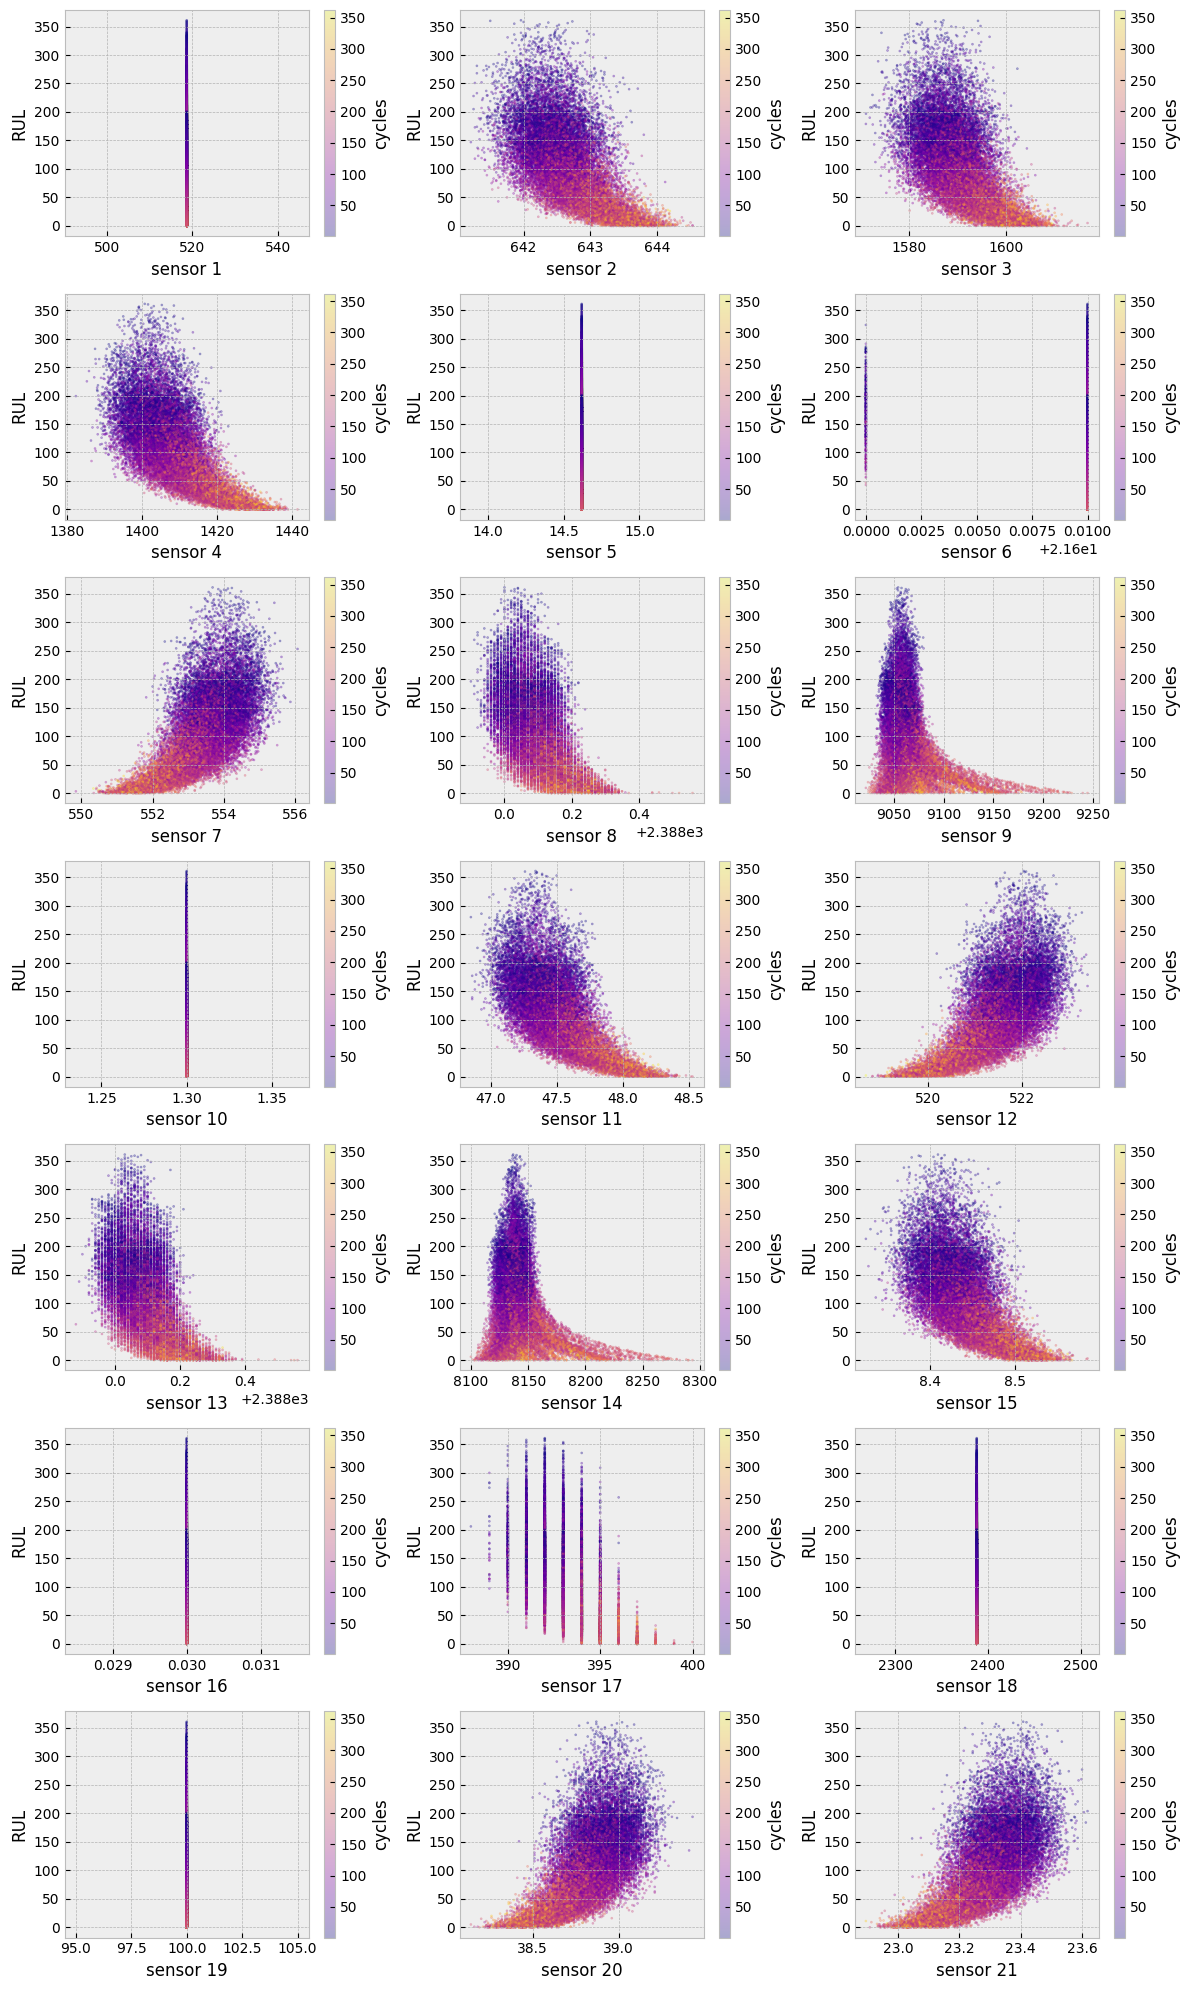

In [6]:
plot.corr_scatter()

Before we continue to use the dataset, we want to delete coulumns that do not contain useful data.

In [37]:
data.train.drop(columns=["setting 3", "sensor 1", "sensor 5", "sensor 6", "sensor 10", "sensor 16", "sensor 18", "sensor 19", ],inplace=True)
data.test.drop(columns=["setting 3", "sensor 1", "sensor 5", "sensor 6", "sensor 10", "sensor 16", "sensor 18", "sensor 19", ],inplace=True)

Some of the data in the datasets may not contribute to training ML algorithms. Examples of these are sensor 1, 5, 6, 10, 16, 18 and 19 which remains constant through the cycles and thus contains 0 variance. This can be seen in the previous scatterplots.

Good training depends on the use of feautures that has high corelation to the target. A perfect line from bottom left to top right in the previous plots would suggest a correlation of 1. The sensors that resembles this may have the most correlation to the target RUL. To aid in this determination, we can also calculate corelations numerically.

#### Correlation heatmap
Plotting a heatmap makes it possible to deremine features correlation to the target, while also see if any features correlate to each other. In the latter case, one of these two features may be dropped.

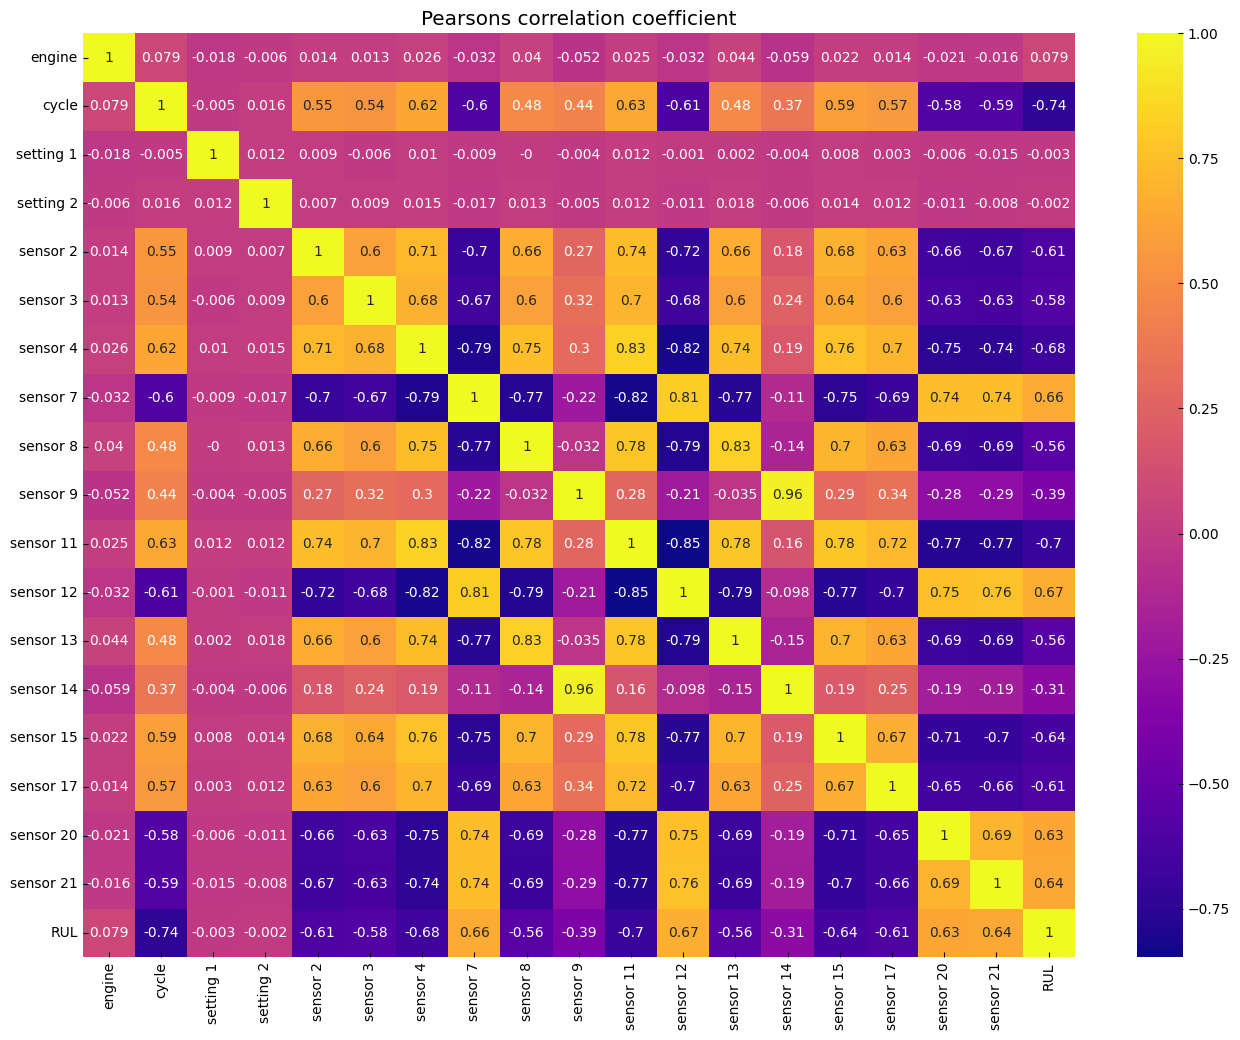

In [38]:
plot.corr_heatmap(data.train, "Pearsons correlation coefficient", 'pearson')

Analyzing the heatmaps, it becomes clear that some sensors have a high correlation to RUL. These are Sensors 7, 12, 20 and 21. Sensor 9 and Sensor 14 have a very high correlation to each other, but since none of them has a substatial correlation to the target, both can be dropped together with the rest of the low-correlation features.

None of the timeseries has outliers, this is good, however some measurements vary more in values than others. To continue, we define a list of the features we want to use, and continue with them.

### Data preparation

Defining features and targets

In [39]:
data.features = ["sensor 2", "sensor 4", "sensor 7", "sensor 12", "sensor 15", "sensor 17", "sensor 20", "sensor 21"]
data.target_linear = "RUL" # This target is used if we want our model to predict the linear RUL value
data.target_binary = "failsoon" # This is used if we want to predict if the engine will fail within x cycles

Preparinig data

In [40]:
data.scale_features(data.train)
data.scale_features(data.test)

In [41]:
data.train[data.target_binary] = data.add_failsoon_column(data.train, foresight=20)
data.test[data.target_binary] = data.add_failsoon_column(data.test, foresight=20)

Use the `Prepared` class to store the prepared data

In [42]:
prepared = Prepared(data.train, data.test)

Generate sequences with 30 timesteps and store in the `Prepared` class, as necessary for the RNN's

In [43]:
prepared.train_sequence = data.generate_sequence(data.train, 30);
prepared.test_sequence = data.generate_sequence(data.test, 30);

In [44]:
prepared.train_sequence.shape

(20601, 30, 8)

Generate label dataframes for validation and later plotting

In [45]:
prepared.train_label = data.generate_label_df(prepared.train, data.target_binary, prepared.train_sequence)
prepared.test_label = data.generate_label_df(prepared.test, data.target_binary, prepared.test_sequence)

### Building the model structures

Necessary preparations

In [46]:
from keras.backend import clear_session
from keras.models import Sequential
from keras.layers import Dense, GRU, Dropout, SimpleRNN, LSTM, Activation
sequence_length = prepared.train_sequence.shape[2]
feature_vector_length = prepared.train_sequence.shape[1]
clear_session() # Ensure same ouput if notebook is executed multiple times

#### LSTM

In [47]:
lstm = Sequential()
lstm.add(LSTM(40, input_shape=(feature_vector_length, sequence_length), return_sequences=True))
lstm.add(Dropout(0.2))
lstm.add(LSTM(40, return_sequences=False))
lstm.add(Dropout(0.2))
lstm.add(Dense(1))
lstm.add(Activation("linear"))
lstm.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae']) 

#### Simple RNN

In [48]:
rnn = Sequential()
rnn.add(SimpleRNN(40, input_shape=(feature_vector_length, sequence_length), return_sequences=True))
rnn.add(SimpleRNN(40))
rnn.add(Dense(1))
rnn.add(Activation("linear"))
rnn.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae']) 

#### GRU

In [49]:
gru = Sequential()
gru.add(GRU(40, input_shape=(feature_vector_length, sequence_length), return_sequences=True))
gru.add(Dropout(0.2))
gru.add(GRU(40))
gru.add(Dropout(0.2))
gru.add(Dense(1))
gru.add(Activation("linear"))
gru.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae']) 

### Training

In [ ]:
lstm_result = lstm.fit(prepared.train_sequence, prepared.train_label, epochs=30, batch_size=200, validation_split=0.05, verbose=1)

In [ ]:
rnn_result = rnn.fit(prepared.train_sequence, prepared.train_label, epochs=30, batch_size=200, validation_split=0.05, verbose=1)

In [ ]:
gru_result = gru.fit(prepared.train_sequence, prepared.train_label, epochs=30, batch_size=200, validation_split=0.05, verbose=1)

### Evaluation of training results

#### LSTM

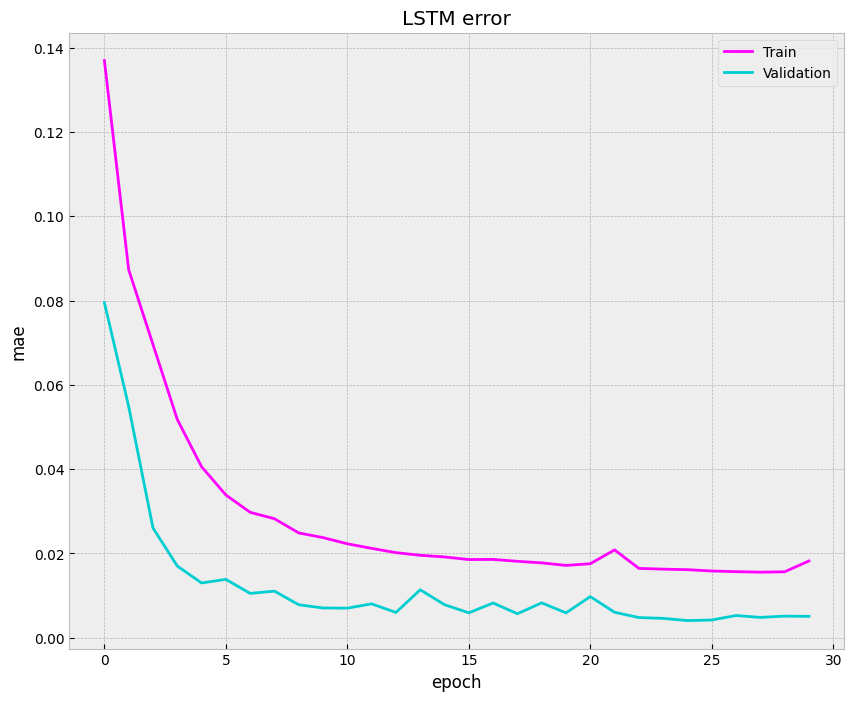

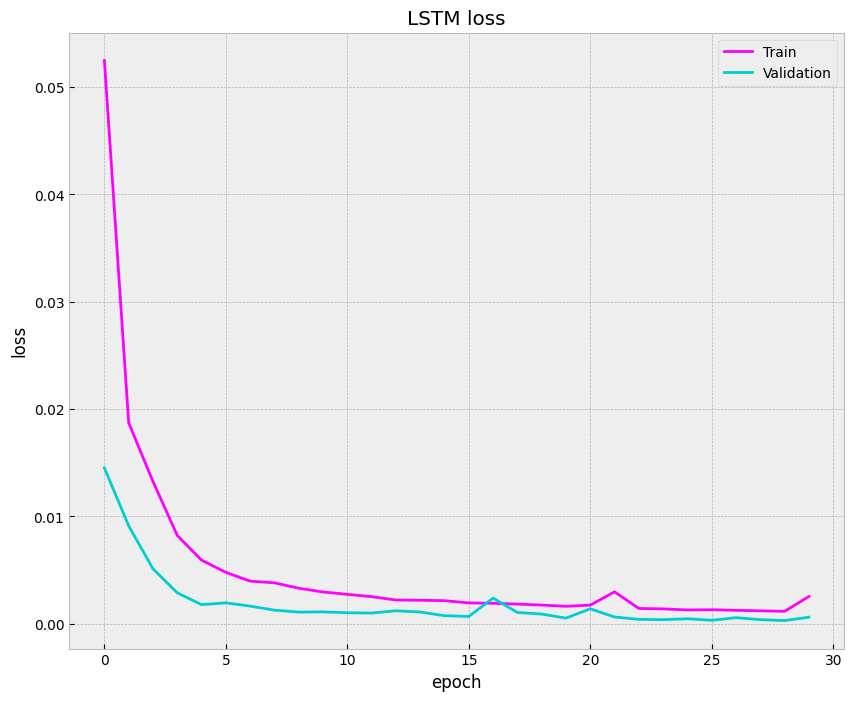

In [53]:
plot.fit_evaluation(lstm_result, 'mae', "LSTM error")
plot.fit_evaluation(lstm_result, 'loss', "LSTM loss")

#### Simple RNN

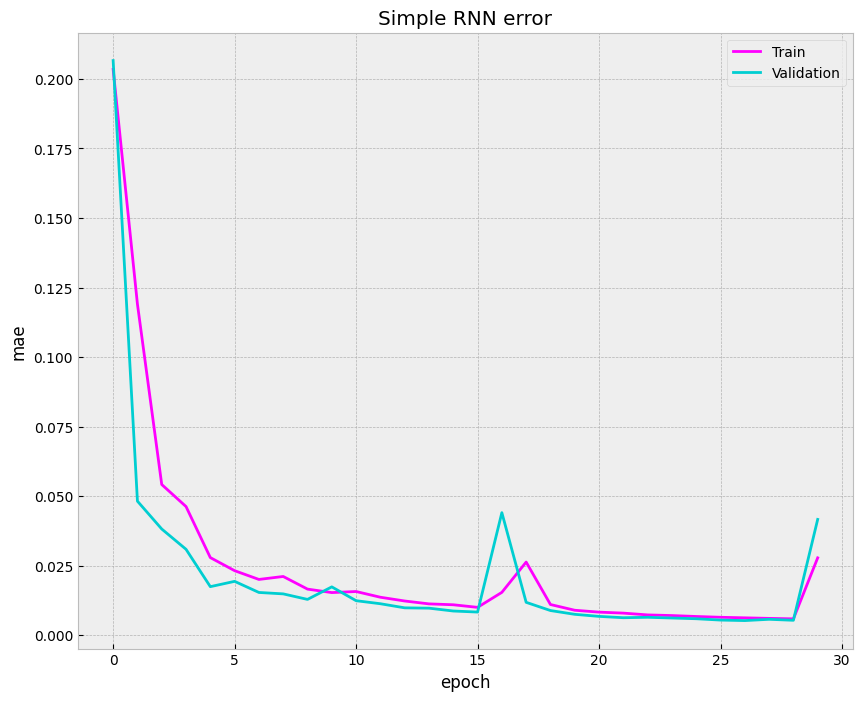

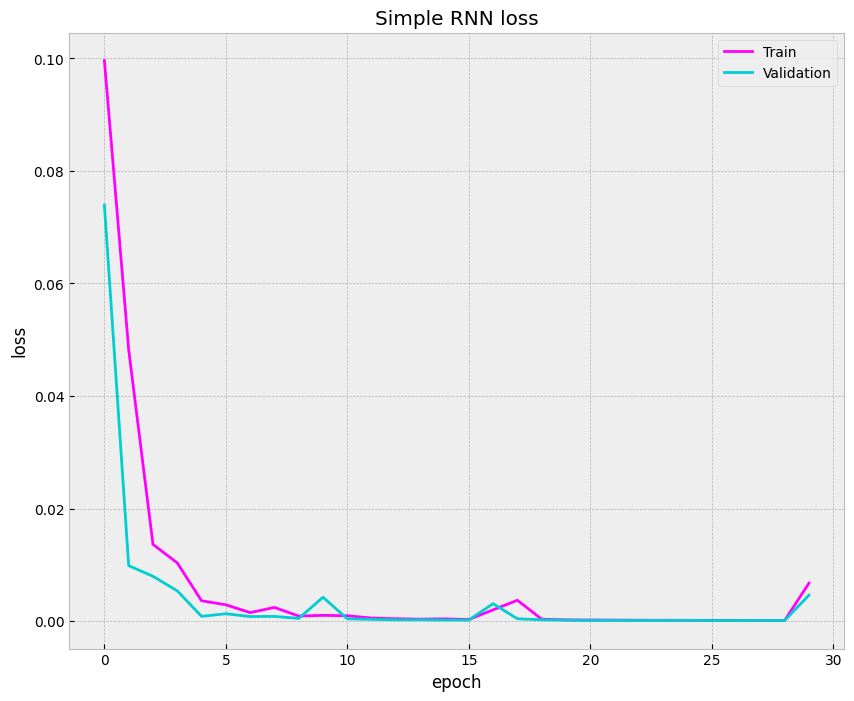

In [54]:
plot.fit_evaluation(rnn_result, 'mae', "Simple RNN error")
plot.fit_evaluation(rnn_result, 'loss', "Simple RNN loss")


#### GRU

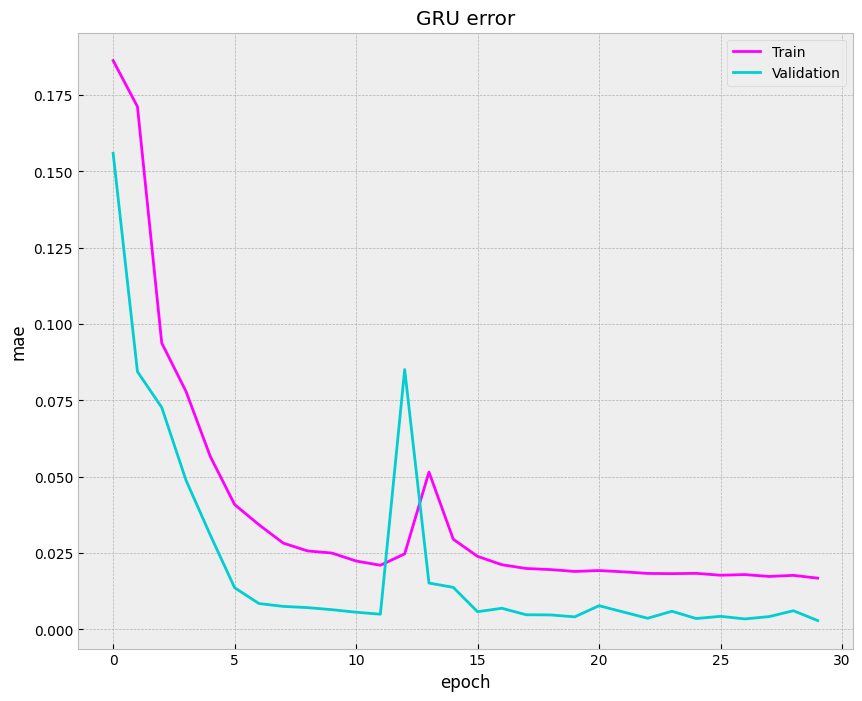

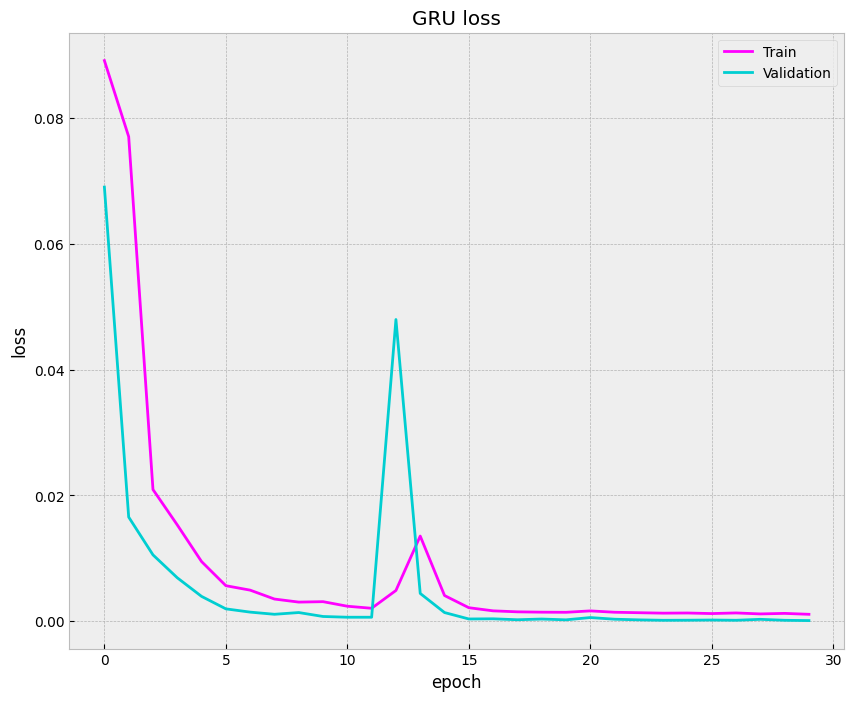

In [55]:
plot.fit_evaluation(gru_result, 'mae', "GRU error")
plot.fit_evaluation(gru_result, 'loss', "GRU loss")

### Prediction

Using the trained models to predict failsoon-condition based on the test dataset

In [56]:
lstm_pred = lstm.predict(prepared.test_sequence)
rnn_pred = rnn.predict(prepared.test_sequence)
gru_pred = gru.predict(prepared.test_sequence)

644/644 [==============================] - 12s 15ms/step

644/644 [==============================] - 5s 7ms/step

644/644 [==============================] - 7s 10ms/step


### Evaluation of predictions

#### LSTM

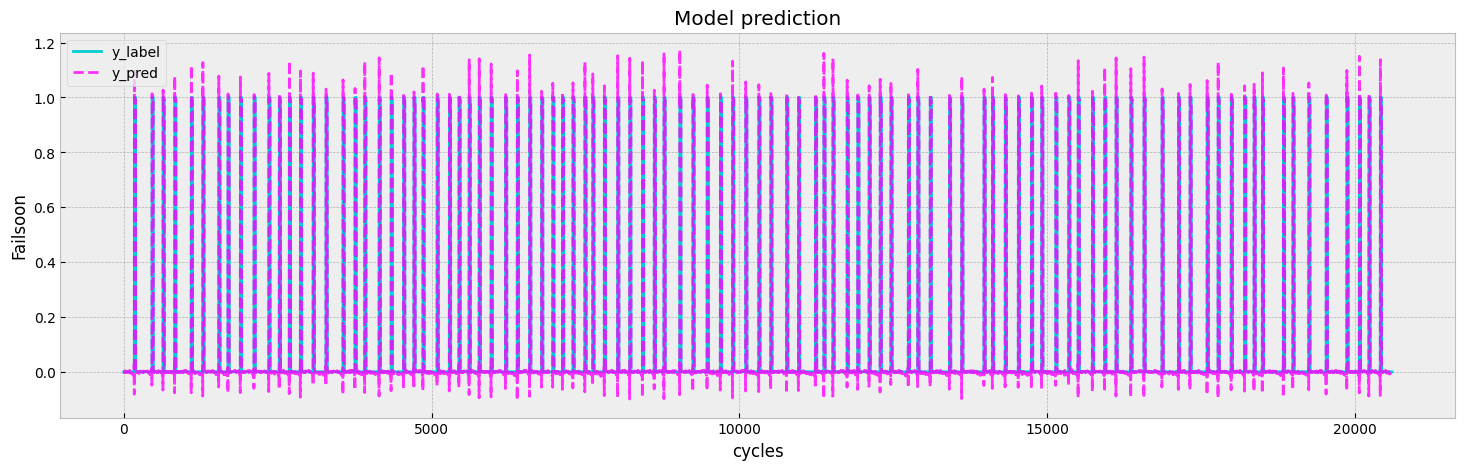

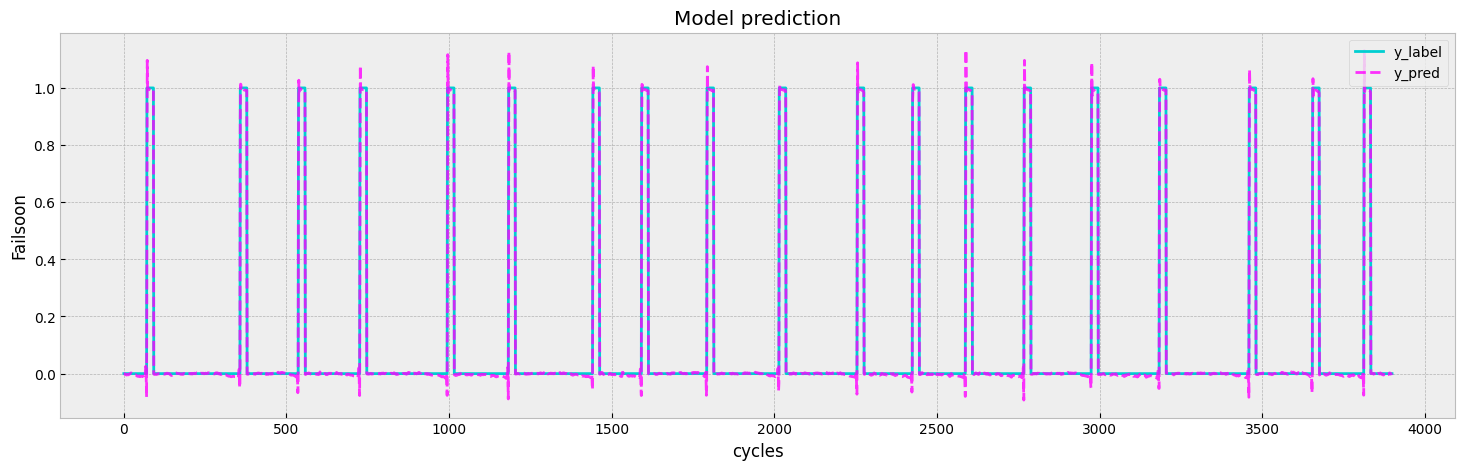

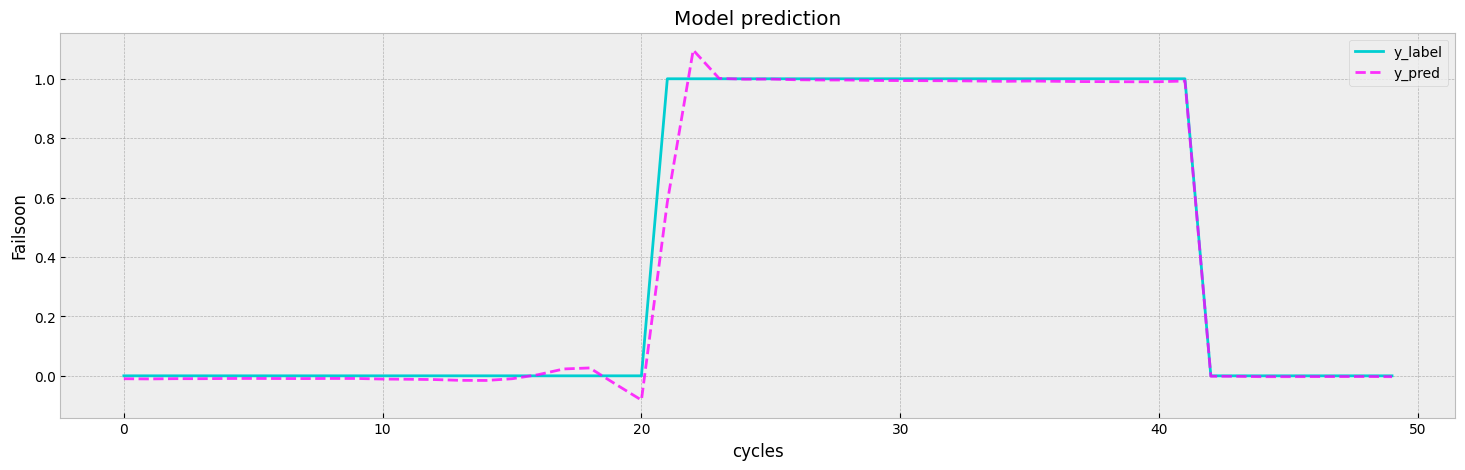

In [57]:
plot.pred_evaluation(prepared.test_label, lstm_pred, 0, lstm_pred.shape[0])
plot.pred_evaluation(prepared.test_label, lstm_pred, 100, 4000)
plot.pred_evaluation(prepared.test_label, lstm_pred, 150, 200)

#### Simlpe RNN

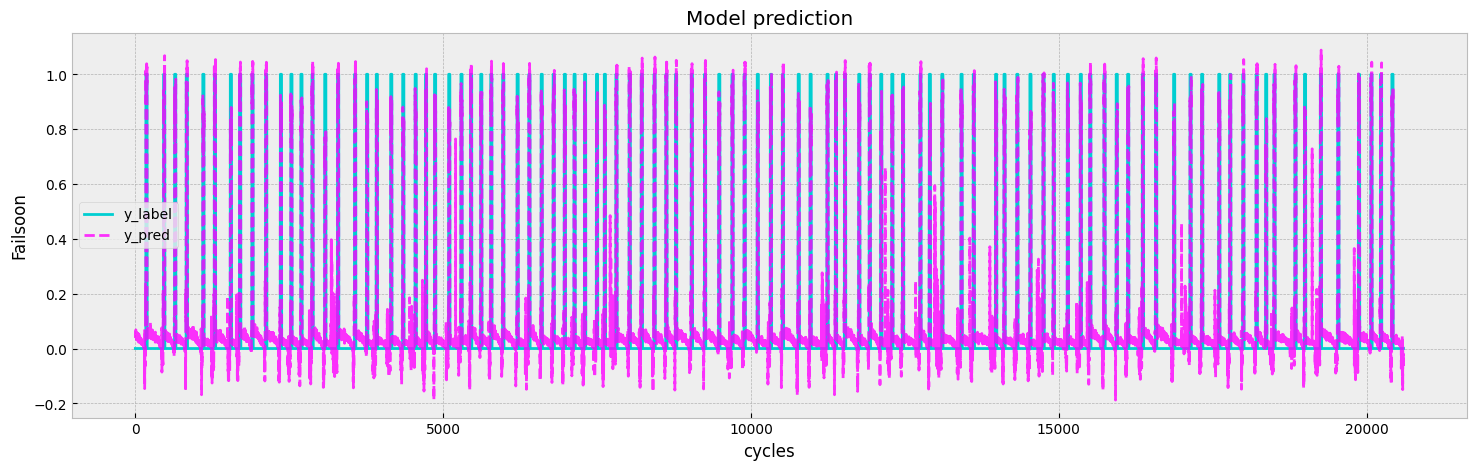

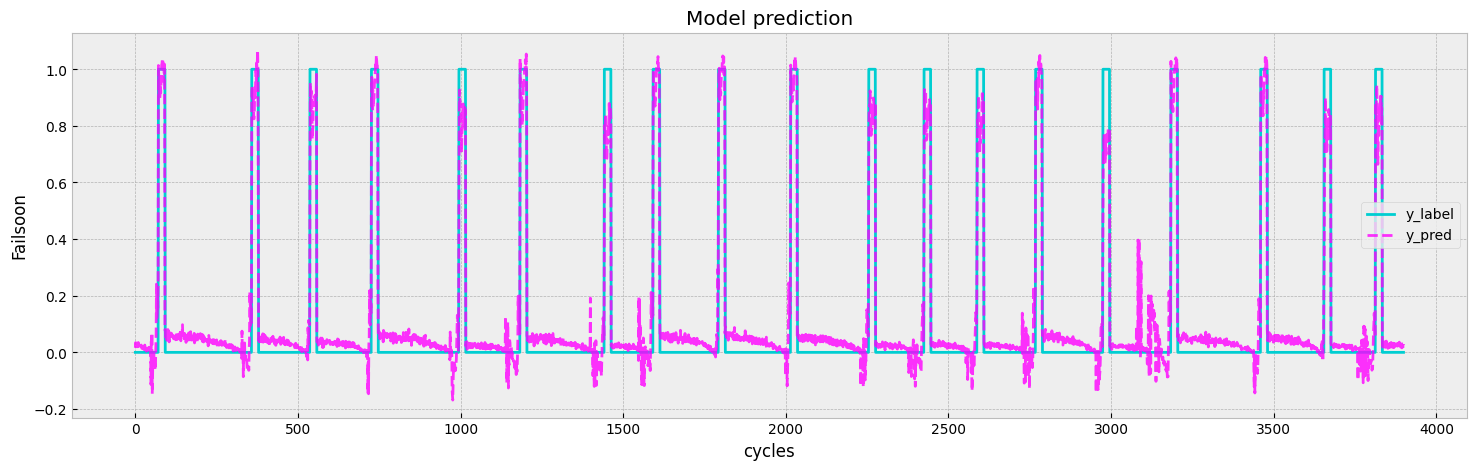

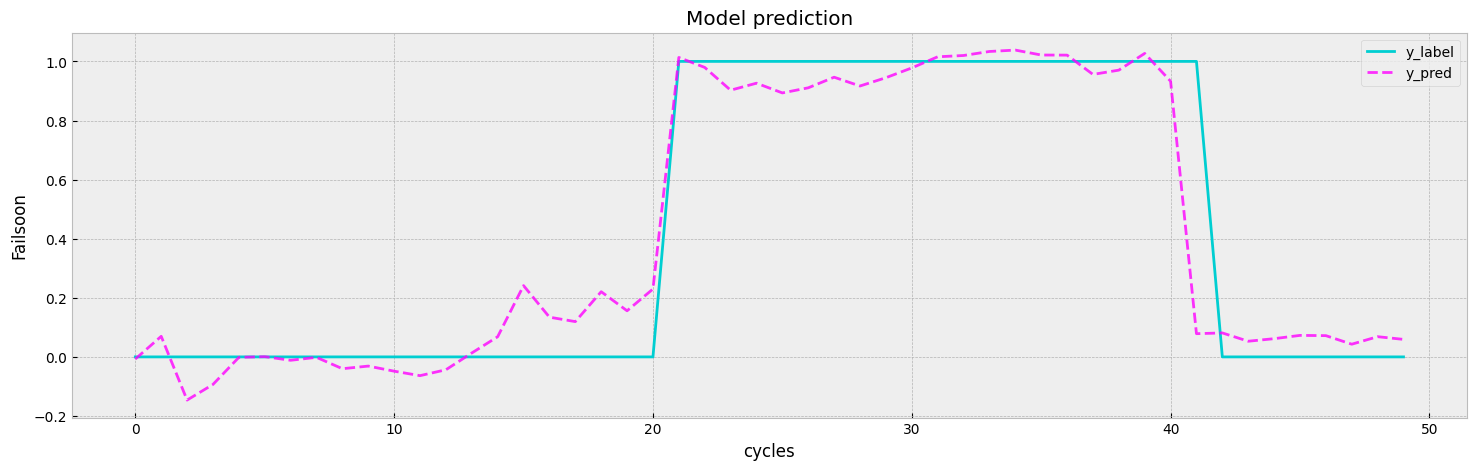

In [58]:
plot.pred_evaluation(prepared.test_label, rnn_pred, 0, rnn_pred.shape[0])
plot.pred_evaluation(prepared.test_label, rnn_pred, 100, 4000)
plot.pred_evaluation(prepared.test_label, rnn_pred, 150, 200)

#### GRU

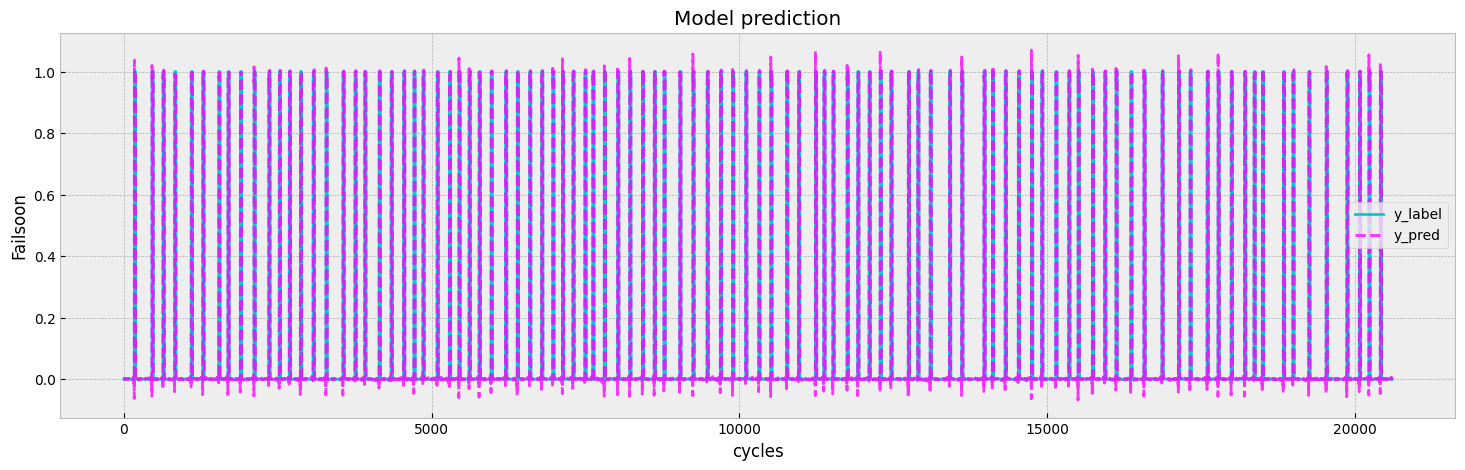

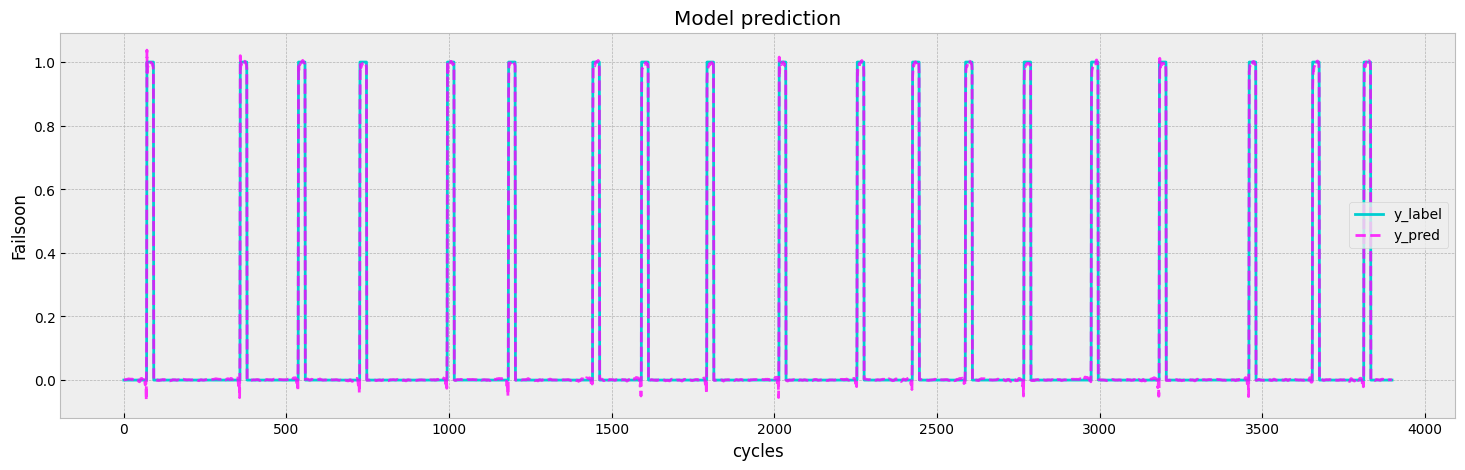

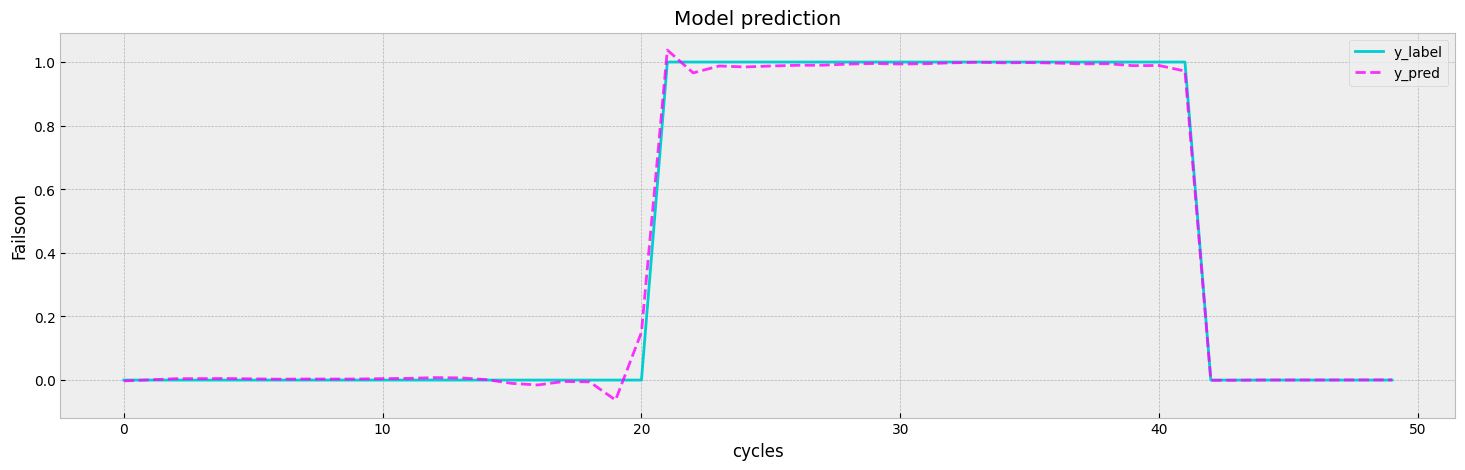

In [59]:
plot.pred_evaluation(prepared.test_label, gru_pred, 0, gru_pred.shape[0])
plot.pred_evaluation(prepared.test_label, gru_pred, 100, 4000)
plot.pred_evaluation(prepared.test_label, gru_pred, 150, 200)

#### References
https://stackoverflow.com/questions/36992855/keras-how-should-i-prepare-input-data-for-rnn

https://www.kaggle.com/code/nafisur/predictive-maintenance-using-lstm-on-sensor-data/notebook

https://www.kaggle.com/code/vinayak123tyagi/damage-propagation-modeling-for-aircraft-engine

https://keras.io/api/layers/recurrent_layers/lstm/

https://keras.io/guides/sequential_model/

https://towardsdatascience.com/object-oriented-programming-for-data-scientists-build-your-ml-estimator-7da416751f64

https://towardsdatascience.com/7-tips-to-choose-the-best-optimizer-47bb9c1219e

https://towardsdatascience.com/understanding-rmsprop-faster-neural-network-learning-62e116fcf29a

https://www.sciencedirect.com/science/article/abs/pii/S0263224119305706


